# Tutorial: Understanding Vodes Through Physics and Energy
## Introduction to Predictive Coding and Value Nodes

Welcome! In this tutorial, we'll explore **Vodes** (Value Nodes) from a physics and differential equations perspective.

### What are Vodes?

In predictive coding, the brain is modeled as a system that constantly generates predictions about sensory input
and minimizes prediction errors. This is analogous to physical systems minimizing energy.

A **Vode** (Vectorised Node) represents a state variable in this system:
- **h** (hidden state): The prediction made by the node
- **u** (input): The actual signal received
- **Energy**: A measure of prediction error (like potential energy in physics)

The system evolves to minimize total energy through gradient descent, similar to how 
physical systems evolve toward equilibrium.

In [2]:
import pcx
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

import pcx as px
import pcx.predictive_coding as pxc
import pcx.nn as pxnn
import pcx.functional as pxf
import pcx.utils as pxu

px.RKG.seed(42)

## Part 1: Understanding a Single Vode

Let's start with the simplest case: a single Vode that learns to predict a target value.

### The Energy Landscape

For a Vode with Gaussian (squared error) energy:

$$E(h, u) = \frac{1}{2}||h - u||^2$$

where:
- $h$ is the predicted state
- $u$ is the input activation

This is analogous to a spring's potential energy: $E = \frac{1}{2}k(x - x_0)^2$

In [5]:
# Create a simple Vode
vode = pxc.Vode(energy_fn=pxc.se_energy)

# Set the input (like applying a force to a spring)
target = jnp.array([5.0])

# Initialize h to some random value (like displacing the spring)
vode(target)  # This sets u and initializes the shape
vode.set("h", jnp.array([0.0]))  # Now set h to starting position

print(f"Initial state h: {vode.get('h')}")
print(f"Target u: {vode.get('u')}")
print(f"Initial energy: {float(vode.energy())}")

Initial state h: [0.]
Target u: [5.]
Initial energy: 12.5


## Part 2: Gradient Descent as Energy Minimization

In physics, systems evolve according to:

$$\frac{dh}{dt} = -\nabla_h E(h, u)$$

This is steepest descent - the system "rolls downhill" in the energy landscape.

For squared error: $\nabla_h E = h - u$

With learning rate $\alpha$:

$$h_{t+1} = h_t - \alpha \nabla_h E$$

In [ ]:
# Let's implement this manually first
vode(jnp.array([5.0]))  # Re-initialize with target
vode.set("h", jnp.array([0.0]))  # Reset to initial position

learning_rate = 0.1
num_steps = 25
h_trajectory = [vode.get("h").item()]

print("Manual gradient descent:")
for step in range(num_steps):
    h = vode.get("h")
    u = vode.get("u")
    
    # Compute gradient: ∇_h E = h - u
    gradient = h - u
    
    # Update: h = h - α * ∇_h E
    new_h = h - learning_rate * gradient
    vode.set("h", new_h)
    
    # IMPORTANT: Clear only the energy from cache to force recomputation
    cache = vode.cache.get()
    if "E" in cache:
        del cache["E"]
    vode.cache.set(cache)
    
    h_trajectory.append(new_h.item())
    
    print(f"Step {step+1}: h = {new_h.item():.4f}, E = {float(vode.energy()):.4f}")

Manual gradient descent:
Step 1: h = 0.5000, E = 10.1250
Step 2: h = 0.9500, E = 8.2013
Step 3: h = 1.3550, E = 6.6430
Step 4: h = 1.7195, E = 5.3808
Step 5: h = 2.0475, E = 4.3585
Step 6: h = 2.3428, E = 3.5304
Step 7: h = 2.6085, E = 2.8596
Step 8: h = 2.8477, E = 2.3163
Step 9: h = 3.0629, E = 1.8762
Step 10: h = 3.2566, E = 1.5197
Step 11: h = 3.4309, E = 1.2310
Step 12: h = 3.5879, E = 0.9971
Step 13: h = 3.7291, E = 0.8076
Step 14: h = 3.8562, E = 0.6542
Step 15: h = 3.9705, E = 0.5299
Step 16: h = 4.0735, E = 0.4292
Step 17: h = 4.1661, E = 0.3477
Step 18: h = 4.2495, E = 0.2816
Step 19: h = 4.3246, E = 0.2281
Step 20: h = 4.3921, E = 0.1848
Step 21: h = 4.4529, E = 0.1497
Step 22: h = 4.5076, E = 0.1212
Step 23: h = 4.5569, E = 0.0982
Step 24: h = 4.6012, E = 0.0795
Step 25: h = 4.6411, E = 0.0644


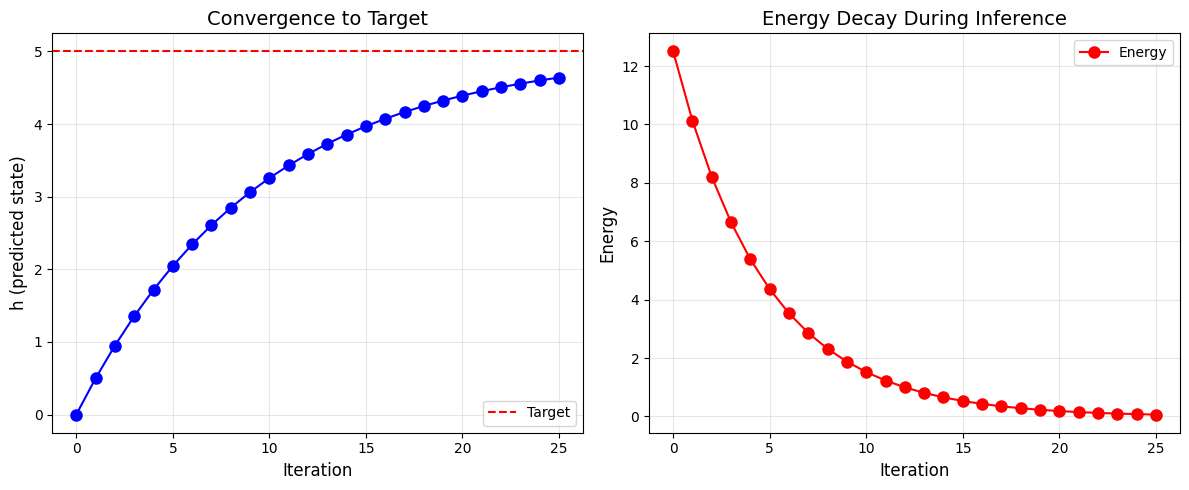

In [6]:
# Visualize the trajectory
plt.figure(figsize=(12, 5))

# Plot 1: h over time
plt.subplot(1, 2, 1)
steps = range(len(h_trajectory))
plt.plot(steps, h_trajectory, 'bo-', markersize=8)
plt.axhline(y=target[0], color='r', linestyle='--', label='Target')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('h (predicted state)', fontsize=12)
plt.title('Convergence to Target', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Energy over time
plt.subplot(1, 2, 2)
# Compute energy for each h value: E = 0.5 * (h - u)^2
energies = [0.5 * (h - target[0])**2 for h in h_trajectory]
plt.plot(steps, energies, 'ro-', markersize=8, label='Energy')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Energy', fontsize=12)
plt.title('Energy Decay During Inference', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 3: Using PCX's Built-in Gradient Computation

PCX provides automatic differentiation through JAX. Let's use the proper PCX workflow:

In [ ]:
# Single vode update using PCX
vode(jnp.array([5.0]))  # Re-initialize
vode.set("h", jnp.array([0.0]))

print("Using PCX automatic differentiation:")
for step in range(20):
    # Get current h value
    h_current = vode.get("h")
    u_current = vode.get("u")
    
    # Compute energy for current state
    energy_val = vode.energy()
    
    # Compute gradient analytically (we know for SE energy: grad = h - u)
    # Or use JAX's grad on a pure function
    def pure_energy_fn(h_val):
        # Squared error energy: 0.5 * (h - u)^2
        return 0.5 * jnp.sum((h_val - u_current) ** 2)
    
    gradient = jax.grad(pure_energy_fn)(h_current)
    
    # Update h
    new_h = h_current - 0.5 * gradient
    vode.set("h", new_h)
    
    # Clear cache for next iteration
    cache = vode.cache.get()
    if "E" in cache:
        del cache["E"]
    vode.cache.set(cache)
    
    print(f"Step {step+1}: h = {new_h.item():.4f}, E = {float(energy_val):.4f}, grad = {gradient.item():.4f}")

Using PCX automatic differentiation:


TypeError: se_energy() missing 1 required positional argument: 'vode'

## Part 4: Custom Energy Functions

You can define any energy function! Let's create a custom "harmonic oscillator" energy:

$$E(h, u) = \frac{1}{2}k(h - u)^2 + \frac{1}{2}m h^2$$

The first term pulls h toward u (like a spring), the second term pulls h toward 0 (like gravity).

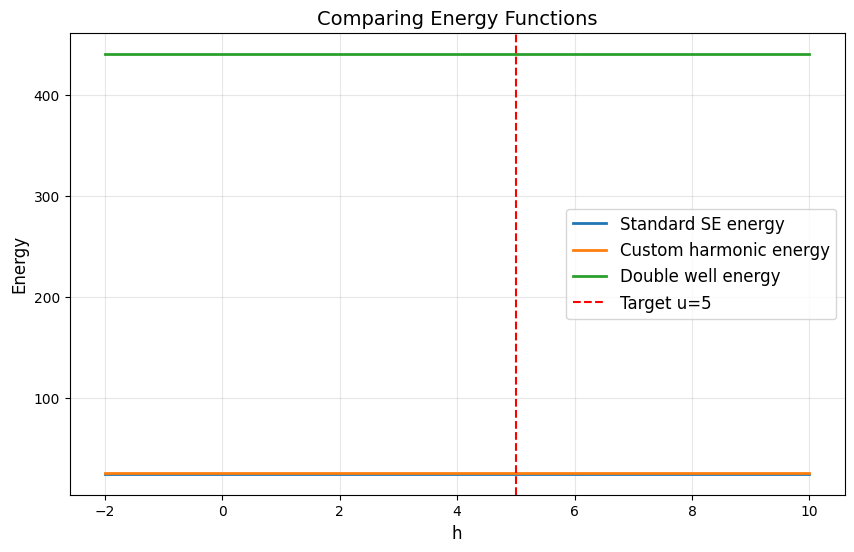

Standard energy minimum: h ≈ 5.0
Custom energy minimum: h ≈ 4.17 (between 0 and u)


In [8]:
def harmonic_energy(vode, rkg=px.RKG):
    """Custom energy: spring + gravity"""
    h = vode.get("h")
    u = vode.get("u")
    
    k = 1.0  # spring constant
    m = 0.2  # "mass" term
    
    spring_energy = 0.5 * k * (h - u) ** 2
    gravity_energy = 0.5 * m * h ** 2
    
    return spring_energy + gravity_energy

def double_well_energy(vode, rkg=px.RKG):
    h = vode.get("h")
    u = vode.get("u")
    
    spring_energy = (h**2 - u**2) ** 2
    return spring_energy

# Create vode with custom energy
custom_vode = pxc.Vode(energy_fn=harmonic_energy)
harmonic_vode = pxc.Vode(energy_fn=double_well_energy)

custom_vode(jnp.array([5.0]))  # Initialize properly
harmonic_vode(jnp.array([5.0]))  # Initialize properly
harmonic_vode.set("h", jnp.array([0.0]))  # Initialize properly
custom_vode.set("h", jnp.array([0.0]))

# Compare energy landscapes
h_vals = jnp.linspace(-2, 10, 100)
standard_energies = []
custom_energies = []
harmonic_energies = []

standard_vode = pxc.Vode(energy_fn=pxc.se_energy)
standard_vode(jnp.array([5.0]))  # Initialize properly

for h in h_vals:
    standard_vode.set("h", jnp.array([h]))
    standard_energies.append(float(standard_vode.energy()))
    
    custom_vode.set("h", jnp.array([h]))
    custom_energies.append(float(custom_vode.energy()))
    
    harmonic_vode.set("h", jnp.array([h]))
    harmonic_energies.append(float(harmonic_vode.energy()))

plt.figure(figsize=(10, 6))
plt.plot(h_vals, standard_energies, label='Standard SE energy', linewidth=2)
plt.plot(h_vals, custom_energies, label='Custom harmonic energy', linewidth=2)
plt.plot(h_vals, harmonic_energies, label='Double well energy', linewidth=2)
plt.axvline(x=5.0, color='r', linestyle='--', label='Target u=5')
plt.xlabel('h', fontsize=12)
plt.ylabel('Energy', fontsize=12)
plt.title('Comparing Energy Functions', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Standard energy minimum: h ≈ {5.0}")
print(f"Custom energy minimum: h ≈ {5.0 / (1 + 0.2):.2f} (between 0 and u)")

### 🎯 Exercise 2: Create Your Own Energy Function

**Task**: Create an energy function that:
1. Has a "double well" potential (two minima)
2. Formula: E(h) = (h² - a²)² where a controls the well locations

**Your code here:**

SOLUTION SPACE

## Part 5: Parallelization with JAX Primitives

Real neural networks process batches of data. PCX uses JAX's `vmap` to automatically
parallelize computations across batch dimensions.

This is like having multiple independent physical systems evolving in parallel!

In [14]:
# Create a batch of targets
batch_size = 4
targets = jnp.array([1.0, 3.0, 5.0, 7.0])

print(f"Batch of {batch_size} targets: {targets}")

Batch of 4 targets: [1. 3. 5. 7.]


In [16]:
# WITH vmap - process all at once
# Simplified batched processing
vode_batch = pxc.Vode(energy_fn=pxc.se_energy)

# Initialize the batch vode with targets
vode_batch(targets)
vode_batch.set("h", jnp.zeros_like(targets))

# Do inference steps on the whole batch
for _ in range(5):
    h_current = vode_batch.get("h")
    u_current = vode_batch.get("u")
    
    # Compute gradient for whole batch
    gradient = h_current - u_current
    vode_batch.set("h", h_current - 0.5 * gradient)
    
    # Clear cache
    cache = vode_batch.cache.get()
    if "E" in cache:
        del cache["E"]
    vode_batch.cache.set(cache)

results_parallel = vode_batch.get("h")

print(f"Parallel results: {results_parallel}")

Parallel results: [0.96875 2.90625 4.84375 6.78125]


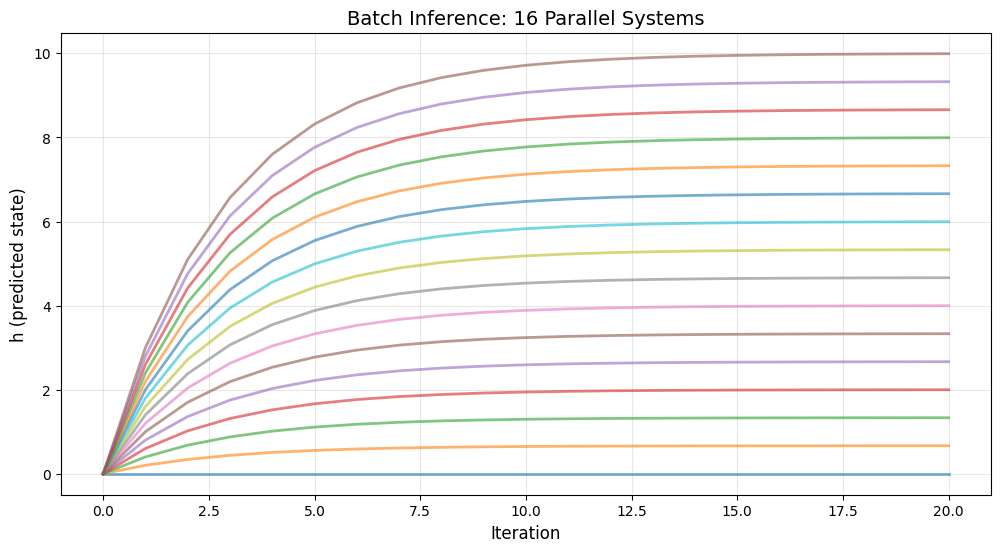

In [12]:
# Let's visualize batch processing
batch_size = 16
targets = jnp.linspace(0, 10, batch_size)

# Simulate batch inference
vode_batch = pxc.Vode(energy_fn=pxc.se_energy)
# Initialize properly
vode_batch(targets)
vode_batch.set("h", jnp.zeros(batch_size))

num_steps = 20
h_history = np.zeros((num_steps + 1, batch_size))
h_history[0] = vode_batch.get("h")

for step in range(num_steps):
    # Compute gradient for whole batch at once (conceptually)
    # In practice, PCX handles this with vmap
    h_current = vode_batch.get("h")
    u_current = vode_batch.get("u")
    gradient = h_current - u_current
    vode_batch.set("h", h_current - 0.3 * gradient)
    
    # Clear cache
    cache = vode_batch.cache.get()
    if "E" in cache:
        del cache["E"]
    vode_batch.cache.set(cache)
    
    h_history[step + 1] = vode_batch.get("h")

# Plot convergence for all batch elements
plt.figure(figsize=(12, 6))
for i in range(batch_size):
    plt.plot(h_history[:, i], alpha=0.6, linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('h (predicted state)', fontsize=12)
plt.title(f'Batch Inference: {batch_size} Parallel Systems', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

## Part 6: Building a Two-Layer Predictive Coding Network

Now let's build a real neural network using Vodes!

**Network structure:**
- Input: 2D points (x, y)
- Hidden layer: 32 neurons with tanh activation
- Output: 2 classes

**Physics interpretation:**
Each layer is a dynamical system trying to predict the next layer's input.
The whole network is a coupled system minimizing total energy.

In [13]:
from typing import Callable

class TwoLayerPC(pxc.EnergyModule):
    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
        output_dim: int,
        act_fn: Callable[[jax.Array], jax.Array]
    ):
        super().__init__()
        
        self.act_fn = px.static(act_fn)
        
        # Create layers (weights)
        self.layer1 = pxnn.Linear(input_dim, hidden_dim)
        self.layer2 = pxnn.Linear(hidden_dim, output_dim)
        
        # Create vodes (states)
        self.vode1 = pxc.Vode(energy_fn=pxc.se_energy)  # Hidden layer state
        self.vode2 = pxc.Vode(energy_fn=pxc.ce_energy)  # Output layer state
        
        # Freeze output label during training
        self.vode2.h.frozen = True
    
    def __call__(self, x, y=None):
        # Forward pass through network
        # Layer 1: x -> W1 -> activate -> vode1
        x = self.vode1(self.act_fn(self.layer1(x)))
        
        # Layer 2: vode1.h -> W2 -> vode2
        x = self.vode2(self.layer2(x))
        
        # Set target label if provided
        if y is not None:
            self.vode2.set("h", y)
        
        return self.vode2.get("u")

In [14]:
# Create the model
model = TwoLayerPC(
    input_dim=2,
    hidden_dim=32,
    output_dim=2,
    act_fn=jax.nn.tanh
)

print("Model created!")
print(f"Layer 1: {model.layer1.nn.weight.shape}")
print(f"Layer 2: {model.layer2.nn.weight.shape}")
print(f"Vode 1 (hidden states): {model.vode1}")
print(f"Vode 2 (output states): {model.vode2}")

Model created!
Layer 1: (32, 2)
Layer 2: (2, 32)
Vode 1 (hidden states): (Vode):
  .h: VodeParam(None)
  .cache: Cache(params=None)
Vode 2 (output states): (Vode):
  .h: VodeParam(None)
  .cache: Cache(params=None)


## Part 7: Training on Two Moons Dataset

We'll use the classic two moons dataset - two interleaving half-circles.

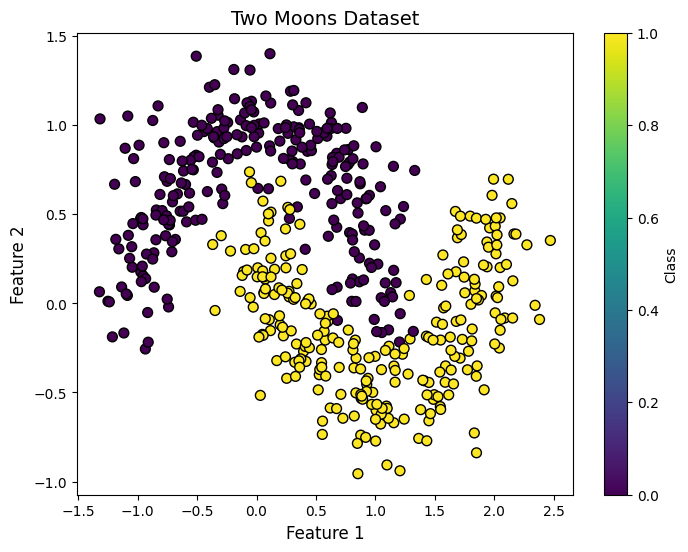

Dataset shape: (512, 2)
Classes: [0 1]


In [15]:
# Generate dataset
n_samples = 512
X, y = make_moons(n_samples=n_samples, noise=0.2, random_state=42)

# Visualize
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)
plt.title('Two Moons Dataset', fontsize=14)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.colorbar(label='Class')
plt.show()

print(f"Dataset shape: {X.shape}")
print(f"Classes: {np.unique(y)}")

In [16]:
# Prepare data loaders
batch_size = 32
n_batches = n_samples // batch_size

X_batches = X.reshape(n_batches, batch_size, 2)
y_batches = y.reshape(n_batches, batch_size)

print(f"Number of batches: {n_batches}")
print(f"Batch shape: X={X_batches[0].shape}, y={y_batches[0].shape}")

Number of batches: 16
Batch shape: X=(32, 2), y=(32,)


## Part 8: The Training Loop - Energy Minimization in Action

**Two-phase optimization:**

1. **Inference phase** (T steps): Minimize energy by updating states h
   - Like letting the physical system equilibrate
   - $h \leftarrow h - \alpha \nabla_h E$

2. **Learning phase** (1 step): Update weights to improve predictions
   - Like adjusting spring constants to better match data
   - $W \leftarrow W - \beta \nabla_W E$

In [17]:
# Define forward pass with batching
@pxf.vmap(pxu.M(pxc.VodeParam | pxc.VodeParam.Cache).to((None, 0)), in_axes=(0, 0), out_axes=0)
def forward(x, y, *, model):
    return model(x, y)

# Define energy computation
@pxf.vmap(pxu.M(pxc.VodeParam | pxc.VodeParam.Cache).to((None, 0)), in_axes=(0,), out_axes=(None, 0), axis_name="batch")
def energy(x, *, model):
    y_pred = model(x, None)
    return jax.lax.psum(model.energy(), "batch"), y_pred

In [18]:
# Training function
@pxf.jit(static_argnums=0)
def train_on_batch(
    T: int,  # Number of inference steps
    x: jax.Array,
    y: jax.Array,
    *,
    model: TwoLayerPC,
    optim_h: pxu.Optim,
    optim_w: pxu.Optim
):
    model.train()
    
    # 1. INITIALIZATION: Forward pass to set initial states
    with pxu.step(model, pxc.STATUS.INIT, clear_params=pxc.VodeParam.Cache):
        forward(x, y, model=model)
    
    # Initialize state optimizer
    optim_h.init(pxu.M_hasnot(pxc.VodeParam, frozen=True)(model))
    
    # 2. INFERENCE: Update states to minimize energy
    for _ in range(T):
        with pxu.step(model, clear_params=pxc.VodeParam.Cache):
            # Compute gradients with respect to states
            (e, y_pred), grads = pxf.value_and_grad(
                pxu.M_hasnot(pxc.VodeParam, frozen=True).to([False, True]),
                has_aux=True
            )(energy)(x, model=model)
        
        # Update states
        optim_h.step(model, grads["model"])
    
    optim_h.clear()
    
    # 3. LEARNING: Update weights
    with pxu.step(model, clear_params=pxc.VodeParam.Cache):
        (e, y_pred), grads = pxf.value_and_grad(
            pxu.M(pxnn.LayerParam).to([False, True]),
            has_aux=True
        )(energy)(x, model=model)
    
    optim_w.step(model, grads["model"], scale_by=1.0/x.shape[0])
    
    return e

In [19]:
# Evaluation function
@pxf.jit()
def eval_on_batch(x: jax.Array, y: jax.Array, *, model: TwoLayerPC):
    model.eval()
    
    with pxu.step(model, pxc.STATUS.INIT, clear_params=pxc.VodeParam.Cache):
        y_pred = forward(x, None, model=model).argmax(axis=-1)
    
    return (y_pred == y).mean()

In [20]:
# Create optimizers
import optax

# State optimizer (fast, for inference)
optim_h = pxu.Optim(lambda: optax.sgd(5e-2, momentum=0.5))

# Weight optimizer (slow, for learning)
optim_w = pxu.Optim(lambda: optax.adamw(1e-2),pxu.M(pxnn.LayerParam)(model))

print("Optimizers created!")

Optimizers created!


In [ ]:
# Initialize with dummy forward pass
with pxu.step(model, pxc.STATUS.INIT, clear_params=pxc.VodeParam.Cache):
    forward(jnp.zeros((batch_size, 2)), None, model=model)

print("Model initialized and ready to train!")

Model initialized and ready to train!


In [22]:
# Training loop
n_epochs = 16
T_inference = 8  # Number of inference steps

print(f"Training for {n_epochs} epochs...")
print(f"Inference steps per batch: {T_inference}")
print()

for epoch in range(n_epochs):
    # Shuffle data
    perm = np.random.permutation(n_batches)
    
    epoch_loss = 0
    for batch_idx in perm:
        x_batch = X_batches[batch_idx]
        y_batch = jax.nn.one_hot(y_batches[batch_idx], 2)
        
        loss = train_on_batch(
            T_inference,
            x_batch,
            y_batch,
            model=model,
            optim_h=optim_h,
            optim_w=optim_w
        )
        epoch_loss += loss
    
    # Evaluate
    acc = np.mean([
        eval_on_batch(X_batches[i], y_batches[i], model=model)
        for i in range(n_batches)
    ])
    
    print(f"Epoch {epoch+1}/{n_epochs} - Loss: {epoch_loss/n_batches:.4f}, Accuracy: {acc*100:.2f}%")

Training for 16 epochs...
Inference steps per batch: 8

Epoch 1/16 - Loss: 12.8065, Accuracy: 80.08%
Epoch 2/16 - Loss: 7.0643, Accuracy: 84.96%
Epoch 3/16 - Loss: 5.0603, Accuracy: 87.30%
Epoch 4/16 - Loss: 4.1696, Accuracy: 88.28%
Epoch 5/16 - Loss: 3.5966, Accuracy: 88.87%
Epoch 6/16 - Loss: 3.2227, Accuracy: 87.89%
Epoch 7/16 - Loss: 2.8409, Accuracy: 89.06%
Epoch 8/16 - Loss: 2.6434, Accuracy: 89.06%
Epoch 9/16 - Loss: 2.3731, Accuracy: 88.87%
Epoch 10/16 - Loss: 2.1566, Accuracy: 89.84%
Epoch 11/16 - Loss: 2.0246, Accuracy: 89.84%
Epoch 12/16 - Loss: 1.9044, Accuracy: 89.84%
Epoch 13/16 - Loss: 1.7635, Accuracy: 90.04%
Epoch 14/16 - Loss: 1.6716, Accuracy: 90.43%
Epoch 15/16 - Loss: 1.5880, Accuracy: 90.43%
Epoch 16/16 - Loss: 1.5006, Accuracy: 90.43%


## Part 9: Visualizing the Learned Decision Boundary

In [23]:
# Create mesh grid
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Predict on grid
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Pad to make it divisible by batch_size
total_points = len(grid_points)
pad_size = (batch_size - (total_points % batch_size)) % batch_size
if pad_size > 0:
    grid_points = np.vstack([grid_points, np.zeros((pad_size, 2))])

grid_batches = grid_points.reshape(-1, batch_size, 2)

# Clear vodes for prediction
model.clear_params(pxc.VodeParam)

predictions = []
for grid_batch in grid_batches:
    with pxu.step(model, pxc.STATUS.INIT, clear_params=pxc.VodeParam.Cache):
        pred = forward(grid_batch, None, model=model).argmax(axis=-1)
    predictions.append(pred)

# Remove padding and reshape
Z = np.concatenate(predictions)[:total_points].reshape(xx.shape)

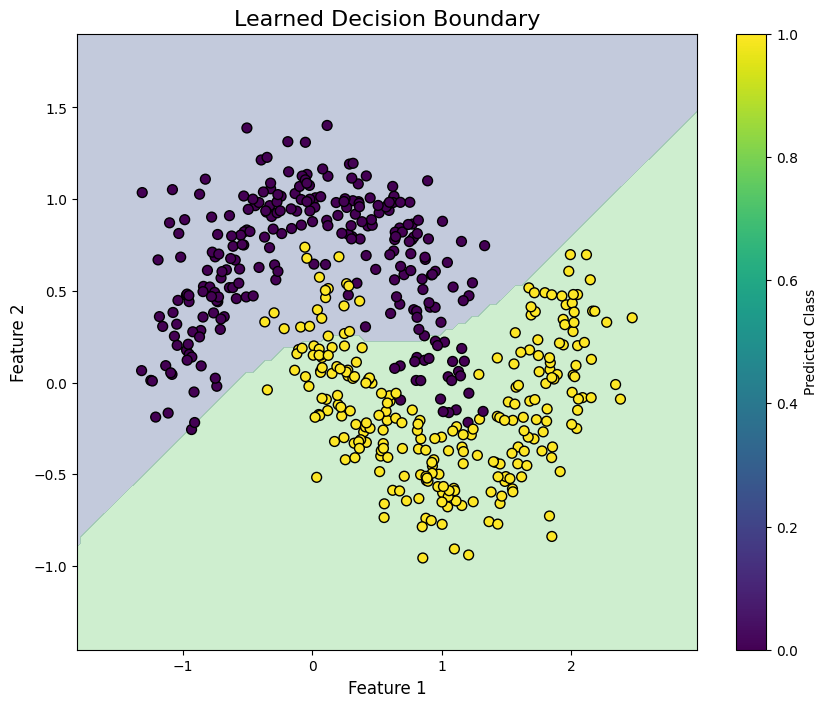

In [24]:
# Plot decision boundary
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis', levels=1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)
plt.title('Learned Decision Boundary', fontsize=16)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.colorbar(label='Predicted Class')
plt.show()

## Part 10: Understanding Energy Flow Through Layers

Let's examine how energy is distributed across the network during inference.

In [25]:
# Track energy during inference for one batch
x_sample = X_batches[0]
y_sample = jax.nn.one_hot(y_batches[0], 2)

# Initialize
with pxu.step(model, pxc.STATUS.INIT, clear_params=pxc.VodeParam.Cache):
    forward(x_sample, y_sample, model=model)

optim_h.init(pxu.M_hasnot(pxc.VodeParam, frozen=True)(model))

# Track energies
n_steps = 20
energy_history = {
    'total': [],
    'vode1': [],
    'vode2': []
}

for step in range(n_steps):
    with pxu.step(model, clear_params=pxc.VodeParam.Cache):
        (e_total, _), grads = pxf.value_and_grad(
            pxu.M_hasnot(pxc.VodeParam, frozen=True).to([False, True]),
            has_aux=True
        )(energy)(x_sample, model=model)
        
        # Get individual energies
        e1 = model.vode1.energy()
        e2 = model.vode2.energy()
    
    energy_history['total'].append(float(e_total))
    energy_history['vode1'].append(float(e1.sum()))
    energy_history['vode2'].append(float(e2.sum()))
    
    optim_h.step(model, grads["model"])

optim_h.clear()

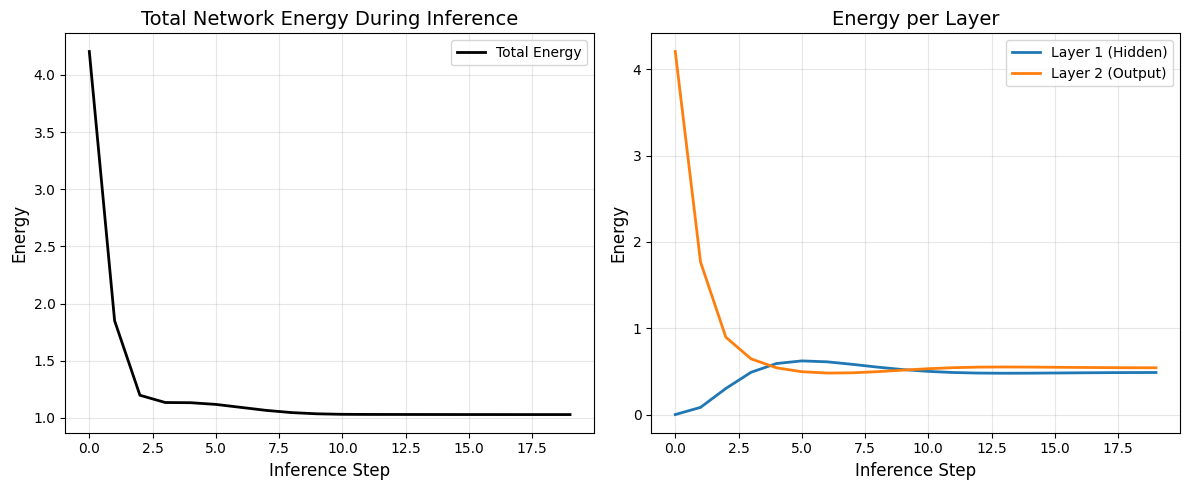


📊 Observations:
• Total energy decreases during inference (system reaches equilibrium)
• Energy flows through layers as states converge to predictions
• This is gradient descent in the energy landscape!


In [26]:
# Plot energy evolution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(energy_history['total'], 'k-', linewidth=2, label='Total Energy')
plt.xlabel('Inference Step', fontsize=12)
plt.ylabel('Energy', fontsize=12)
plt.title('Total Network Energy During Inference', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(energy_history['vode1'], label='Layer 1 (Hidden)', linewidth=2)
plt.plot(energy_history['vode2'], label='Layer 2 (Output)', linewidth=2)
plt.xlabel('Inference Step', fontsize=12)
plt.ylabel('Energy', fontsize=12)
plt.title('Energy per Layer', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Observations:")
print("• Total energy decreases during inference (system reaches equilibrium)")
print("• Energy flows through layers as states converge to predictions")
print("• This is gradient descent in the energy landscape!")

### 🎯 Exercise 3: Explore Different Inference Lengths

**Task**: 
1. Train models with T=4, T=8, and T=16 inference steps
2. Compare final accuracy and training time
3. Plot how accuracy changes with T

**Hint**: More inference steps = more equilibration time = potentially better predictions

**Your code here:**

SOLUTION SPACE

## Summary: Physics ↔ Predictive Coding Analogies

| Physics Concept | Predictive Coding | PCX Implementation |
|----------------|-------------------|-------------------|
| State variable x | Hidden state h | `vode.h` |
| Potential energy V(x) | Prediction error E(h,u) | `vode.energy()` |
| Force F = -∇V | Prediction gradient ∇E | `jax.grad(energy)` |
| Equilibrium (∂V/∂x=0) | Inference convergence | Inference loop |
| System evolution dx/dt | State updates dh/dt | `optim_h.step()` |
| Spring constant k | Weight matrix W | `layer.weight` |
| Multiple particles | Network layers | Multiple vodes |
| Coupled oscillators | Hierarchical predictions | Layered vodes |

### Key Takeaways:

1. **Vodes are dynamical systems** that minimize prediction error (energy)
2. **Inference is relaxation** - letting the system reach equilibrium
3. **Learning adjusts couplings** - changing weights to improve predictions
4. **JAX parallelizes** the physics across batches efficiently
5. **Custom energies** allow modeling different prior beliefs

🎓 **You now understand the deep connection between physics and predictive coding!**

### 🎯 Final Challenge: Build a 3-Layer Network

**Task**: Extend `TwoLayerPC` to a three-layer network:
- Input: 2D
- Hidden 1: 32 neurons (tanh)
- Hidden 2: 16 neurons (tanh) 
- Output: 2 classes

Train it on two moons and compare performance to the 2-layer version.

**Your code here:**

SOLUTION SPACE